# Import and data loading

In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import ast

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
# =========================
# 2. LOAD DATA
# =========================

path = r"C:\Users\hp\Desktop\Major Pr\borg_traces_data.csv"

df = pd.read_csv(path)

print("Shape:", df.shape)
print(df.head())

Shape: (405894, 34)
   Unnamed: 0           time  instance_events_type  collection_id  \
0           0              0                     2    94591244395   
1           1  2517305308183                     2   260697606809   
2           2   195684022913                     6   276227177776   
3           3              0                     2    10507389885   
4           4  1810627494172                     3    25911621841   

   scheduling_class  collection_type  priority  alloc_collection_id  \
0                 3                1       200                    0   
1                 2                0       360         221495397286   
2                 2                0       103                    0   
3                 3                0       200                    0   
4                 2                0         0                    0   

   instance_index    machine_id  ... assigned_memory page_cache_memory  \
0             144  168846390496  ...        0.014435          0.

In [3]:
# =========================
# 3. DATA UNDERSTANDING
# =========================

print("\nColumns:\n", df.columns)

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

print("\nStatistics:")
print(df.describe())


Columns:
 Index(['Unnamed: 0', 'time', 'instance_events_type', 'collection_id',
       'scheduling_class', 'collection_type', 'priority',
       'alloc_collection_id', 'instance_index', 'machine_id',
       'resource_request', 'constraint', 'collections_events_type', 'user',
       'collection_name', 'collection_logical_name',
       'start_after_collection_ids', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'average_usage', 'maximum_usage',
       'random_sample_usage', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution',
       'cluster', 'event', 'failed'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405894 entries, 0 to 405893
Data columns (total 34 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed

# Drop useless columns

In [4]:
# =========================
# 4. DROP USELESS COLUMNS
# =========================

drop_cols = [
    'Unnamed: 0',
    'constraint',
    'user',
    'collection_name',
    'collection_logical_name',
    'start_after_collection_ids',
    'cpu_usage_distribution',
    'tail_cpu_usage_distribution'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Parse dictionary columns

In [5]:
#Parse dictionary columns
{'cpus': 0.02, 'memory': 0.01}

{'cpus': 0.02, 'memory': 0.01}

In [6]:
def extract_value(x, key):
    try:
        return ast.literal_eval(x)[key]
    except:
        return np.nan

In [7]:
#Apply Parsing
df['req_cpu'] = df['resource_request'].apply(lambda x: extract_value(x, 'cpus'))
df['req_mem'] = df['resource_request'].apply(lambda x: extract_value(x, 'memory'))

df['avg_cpu'] = df['average_usage'].apply(lambda x: extract_value(x, 'cpus'))
df['avg_mem'] = df['average_usage'].apply(lambda x: extract_value(x, 'memory'))

df['max_cpu'] = df['maximum_usage'].apply(lambda x: extract_value(x, 'cpus'))
df['max_mem'] = df['maximum_usage'].apply(lambda x: extract_value(x, 'memory'))


In [8]:
df.drop(columns=[
    'resource_request',
    'average_usage',
    'maximum_usage',
    'random_sample_usage'
], inplace=True)

# Feature Engineering

In [9]:
# runtime
df['runtime'] = df['end_time'] - df['start_time']

# scheduling delay
df['delay'] = df['start_time'] - df['time']

# CPU efficiency
df['cpu_efficiency'] = df['avg_cpu'] / (df['req_cpu'] + 1e-6)

# Handle Missing Values

In [10]:
df.fillna({
    'vertical_scaling': 0,
    'scheduler': 0,
    'cycles_per_instruction': df['cycles_per_instruction'].median(),
    'memory_accesses_per_instruction': df['memory_accesses_per_instruction'].median()
}, inplace=True)

df.fillna(0, inplace=True)


"""stats:

vertical_scaling → 959 missing

scheduler → 959 missing

cycles_per_instruction → many missing

memory_accesses_per_instruction → many missing"""

'stats:\n\nvertical_scaling → 959 missing\n\nscheduler → 959 missing\n\ncycles_per_instruction → many missing\n\nmemory_accesses_per_instruction → many missing'

# Encode categorical column

In [11]:
df['event'] = df['event'].astype('category').cat.codes

# Keep only numeric columns

In [12]:
df = df.select_dtypes(include=[np.number])

print("After cleaning shape:", df.shape)

After cleaning shape: (405894, 31)


# Feature Selection

In [13]:
features = [
    'priority',
    'machine_id',
    'req_cpu','req_mem',
    'avg_cpu','avg_mem',
    'max_cpu','max_mem',
    'assigned_memory',
    'page_cache_memory',
    'cycles_per_instruction',
    'memory_accesses_per_instruction',
    'runtime',
    'delay',
    'event',
    'failed'
]

df = df[features]

# Choose Target predict CPU usage

In [14]:
X = df.drop(columns=['avg_cpu'])
y = df['avg_cpu']

# Scaling

In [15]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split 

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (324715, 15)
Test: (81179, 15)


# Save clean dataset

In [17]:
clean_df = pd.concat([pd.DataFrame(X_scaled), y.reset_index(drop=True)], axis=1)

clean_df.to_csv("clean_borg_data.csv", index=False)
print("Clean data saved!")

Clean data saved!


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# target
y = df['avg_cpu']   # or your target column

# numeric features only
X = df.select_dtypes(include=[np.number]).drop(columns=['avg_cpu'])

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

y_train = np.array(y_train)
y_test  = np.array(y_test)


# Autoencoder + MLP (Feature compression)

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, Sequential
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#AutoEncoder
inp = Input(shape=(X_train.shape[1],))

encoded = Dense(64, activation='relu')(inp)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(X_train.shape[1])(decoded)

autoencoder = Model(inp, decoded)
encoder = Model(inp, encoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    X_train, X_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2
)

#Compress Features
X_train_enc = encoder.predict(X_train)
X_test_enc  = encoder.predict(X_test)

print(X_train_enc.shape)

#MLP on encoded features
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_enc.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_enc, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0210 - val_loss: 1.4122e-04
Epoch 2/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0081e-04 - val_loss: 3.2888e-05
Epoch 3/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6423e-05 - val_loss: 1.6225e-05
Epoch 4/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4463e-05 - val_loss: 1.1372e-05
Epoch 5/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0857e-05 - val_loss: 7.6799e-06
Epoch 6/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.2840e-06 - val_loss: 4.4257e-06
Epoch 7/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.9360e-06 - val_loss: 6.9555e-06
Epoch 8/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.6702e-06 - val_loss: 2.1631e-06
Epoch 9/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.6498e-06 - val_loss: 9.3492e-07
Epoch 10/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.6892e-06 - val_loss: 7.2545e-07
10148/10148 ━━━━━━━━━━━━━━━━━━━━ 6s 605us/step
2537/2537 ━━━━━━

C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0057 - mae: 0.0362 - val_loss: 5.8312e-05 - val_mae: 0.0049
Epoch 2/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.4271e-05 - mae: 0.0046 - val_loss: 4.0192e-05 - val_mae: 0.0039
Epoch 3/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.1749e-05 - mae: 0.0038 - val_loss: 3.7977e-05 - val_mae: 0.0039
Epoch 4/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.5503e-05 - mae: 0.0035 - val_loss: 4.0189e-05 - val_mae: 0.0043
Epoch 5/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.2930e-05 - mae: 0.0034 - val_loss: 2.9880e-05 - val_mae: 0.0033
Epoch 6/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3.1070e-05 - mae: 0.0033 - val_loss: 2.8272e-05 - val_mae: 0.0030
Epoch 7/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.9356e-05 - mae: 0.0032 - val_loss: 2.7375e-05 - val_mae: 0.0031
Epoch 8/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.9887e-05 - mae: 0.0034 - val_loss: 3.7035e-05 - val_mae: 0.0044
Epoch 9

In [23]:
y_pred = model.predict(X_test_enc).flatten()

print("\n===== Autoencoder + MLP RESULTS =====")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

2537/2537 ━━━━━━━━━━━━━━━━━━━━ 2s 625us/step

===== Autoencoder + MLP RESULTS =====
MAE : 0.003733807412605434
RMSE: 0.005447975150849958
R2  : 0.9145258738466723


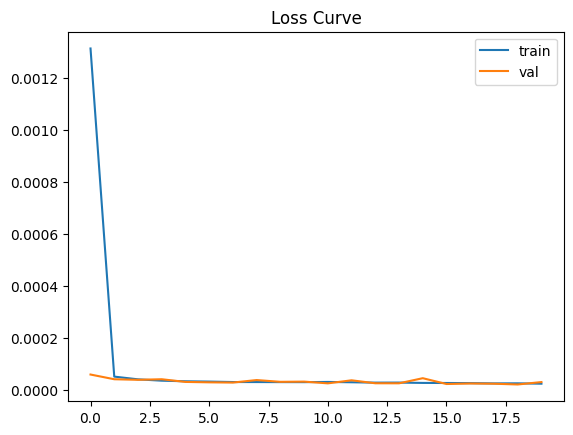

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])
plt.title("Loss Curve")
plt.show()

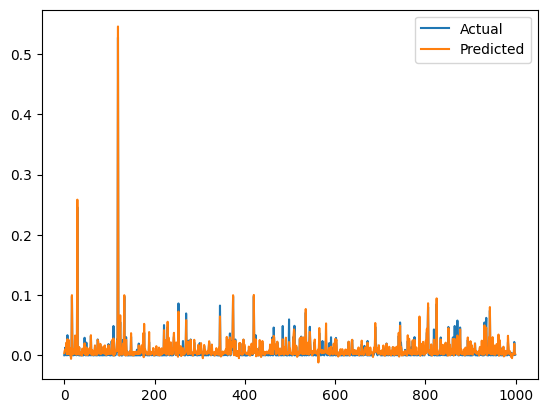

In [25]:
plt.plot(y_test[:1000], label='Actual')
plt.plot(y_pred[:1000], label='Predicted')
plt.legend()
plt.show()

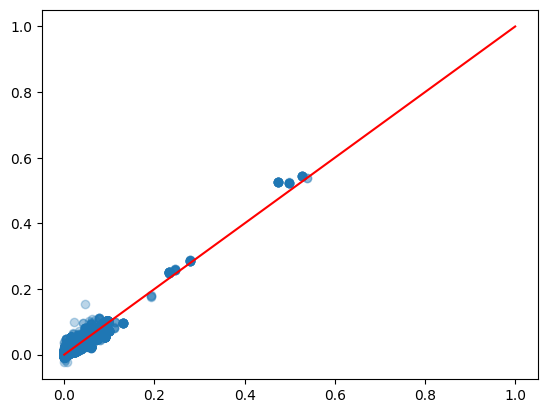

In [26]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0,1],[0,1],'r')
plt.show()

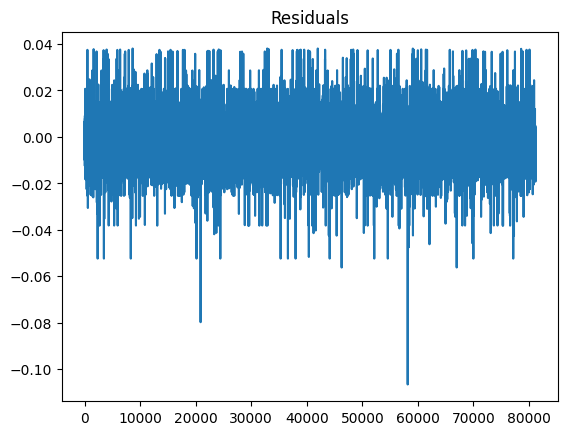

In [27]:
plt.plot(y_test - y_pred)
plt.title("Residuals")
plt.show()